# Практическая работа №1: Формирование и первичная обработка выборки. Ранжированный и интервальный ряды

Выполнили студенты гр. 2381 Дудкин Михаил Валерьевич и Газукина Дарья Денисовна. Вариант №19.

## Цель работы

Ознакомление с основными правилами формирования выборки и подготовки выборочных данных к статистическому анализу.


## Основные теоретические положения

**Генеральная совокупность** — полное множество всех возможных объектов или наблюдений, обладающих определёнными свойствами, подлежащих изучению.

**Выборка** — подмножество объектов, отобранных из генеральной совокупности, обладающее теми же свойствами что и генеральная совокупность.

**Ранжированный ряд** — упорядоченная по возрастанию или убыванию последовательность значений выборки:

$x_{1} \leq x_{2} \leq \dots \leq x_{n}$

**Вариационный ряд** — последовательность различных значений вариационного признака, расположенных в порядке возрастания, с соответствующими им частотами:

$\begin{array}{c|cccc}
x_i & x_1 & x_2 & \dots & x_k \\
\hline
n_i & n_1 & n_2 & \dots & n_k \\
\end{array}$

**Интервальный ряд** — группировка данных, при которой значения признака объединяются в интервалы $[x_i, x_{i+1})$ с подсчётом частот попадания в каждый интервал, количество интервалов зависит от объема выборки:

$\begin{array}{c|cccc}
[x_i, x_{i+1}) & [x_1, x_2) & [x_2, x_3) & \dots & [x_k, x_{k+1}) \\
\hline
n_i & n_1 & n_2 & \dots & n_k \\
\end{array}$

**Полигон частот** — ломаная линия, соединяющая точки $(x_i, n_i)$ или $(x_i, w_i)$, где $n_i$ — абсолютные частоты, $w_i$ — относительные частоты.

**Гистограмма частот** — ступенчатая фигура, состоящая из прямоугольников, основаниями которых служат интервалы $[x_i, x_{i+1})$, а высоты пропорциональны частотам:

$h_i = \frac{n_i}{x_{i+1} - x_i}$

**Эмпирическая функция распределения** — функция, определяющая для каждого значения $x$ относительную частоту событий, меньших $x$:

$F_n(x) = \frac{n_x}{n} = \begin{cases}
    0, & x \leq x_{1} \\
    \frac{k}{n}, & x_{k} < x \leq x_{k+1} \\
    1, & x > x_{n} \\
  \end{cases}$

где $n_x$ — число наблюдений, меньших $x$, $n$ — объём выборки.


## Постановка задачи

Осуществить формирование репрезентативной выборки заданного объема из имеющейся генеральной совокупности экспериментальных данных. Осуществить последовательное преобразование полученной выборки в ранжированный, вариационный и интервальный ряды. Применительно к интервальному ряду построить и отобразить графически полигон, гистограмму и эмпирическую функцию распределения для абсолютных и относительных частот. Полученные результаты содержательно проинтерпретировать.

## Выполнение работы

Импорт необходимых библиотек

In [135]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Подготовим функцию для вывода графиков

In [136]:
def signal_plot(signal, title, T=1, signal2=None):
    time_labels = np.arange(len(signal)) * T  # Если пероид не указан, используется дискретное нормированное время
    plt.figure(figsize=(8, 4))
    plt.stem(time_labels, signal)
    if signal2 is not None:
      plt.stem(time_labels, signal2)
    plt.xlabel('Отсчеты')
    plt.ylabel('Уровень сигнала')
    plt.title(title)
    plt.grid(True)
    plt.show()

# Задание 1

Выбрать программное обеспечение или язык программирования для выполнения практических работ и обосновать его выбор.

В качестве языка программирования был выбран Python, так как он часто используется для анализа данных, предоставляет много инструментов для статистического анализа, прост с точки зрения синтаксиса, наглядный, что облегчает оформление отчёта и понимание алгоритмов преобразования выборки.

# Задание 2

Выбрать двумерную генеральную совокупность, предварительно согласовав её с преподавателем. Указать, откуда была взята генеральная совокупность и предоставить ссылку.

Генеральная совокупность: Данные наблюдения относительно объемного веса ν (г/см³) при влажности 10% и модуля упругости E (кг/см²) при сжатии вдоль волокон древесины резонансной ели (csv-формат) https://se.moevm.info/lib/exe/fetch.php/courses:statistical_methods_of_experimental_data_handling:sample.zip

In [137]:
path = "/content/sample.csv"
data = pd.read_csv(path, comment='#')
data.head(10)

,nu,E
0,480,153.3
1,510,129.4
2,426,119.0
3,482,139.9
4,393,103.2
5,510,162.3
6,403,123.9
7,506,158.4
8,393,122.8
9,442,115.4


# Задание 3

Из генеральной совокупности сформировать выборку заданного объёма в соответствии с полученным от преподавателя номером. Указать, каким образом была сформирована выборка.

In [138]:
# Вариант №19
N = 103   # Объем выборки

In [139]:
df = data.sample(frac=1, random_state=19).reset_index(drop=True)[:N]
df

,nu,E
0,424,119.0
1,409,116.7
2,466,130.3
3,433,130.0
4,466,137.9
...,...,...
98,585,177.7
99,440,126.7
100,434,140.4
101,406,112.4


In [140]:
df.to_csv("sample_103.csv")

Выборка была сформирована путем случайного извлечения 103 строк из генеральной совокупности средстваи библиотеки pandas.

# Задание 4

Последовательно преобразовать выборку в ранжированный, вариационный и интервальный ряды. Интервальный ряд представить в виде табл. 1. Результаты содержательно проинтерпретировать.

In [141]:
# Ранжированный ряд
ranked_series = df['nu'].sort_values().reset_index(drop=True)

print("\nРанжированный ряд (по nu):")
print(ranked_series)


Ранжированный ряд (по nu):
0      330
1      340
2      353
3      358
4      362
      ... 
98     562
99     569
100    572
101    576
102    585
Name: nu, Length: 103, dtype: int64


In [142]:
# Вариационный ряд
variation_series = df['nu'].value_counts().sort_index().reset_index()

print("\nВариационный ряд (по nu):")
print(variation_series)


Вариационный ряд (по nu):
     nu  count
0   330      1
1   340      1
2   353      1
3   358      1
4   362      1
..  ...    ...
73  562      1
74  569      1
75  572      1
76  576      1
77  585      1

[78 rows x 2 columns]


In [143]:
# Интервальный ряд
k = round(1 + 3.322 * np.log10(N))
print(f"По формуле Стерджесса количество интервалов k = {k}")

По формуле Стерджесса количество интервалов k = 8


In [144]:
nu_min = df['nu'].min()
nu_max = df['nu'].max() + 1   # Чтобы максимальный элемент попадал не на границу
range_nu = nu_max - nu_min

interval_width = range_nu / k
intervals = np.linspace(nu_min, nu_max, k + 1)

interval_labels = [f"[{intervals[i]:.1f}-{intervals[i+1]:.1f})" for i in range(k)]
df['nu_interval'] = pd.cut(df['nu'], bins=intervals, labels=interval_labels, right=True)

interval_data = []
for i in range(k):
    # Данные в текущем интервале
    interval_values = df.loc[(df['nu'] >= intervals[i]) & (df['nu'] < intervals[i+1]), 'nu']
    mi = len(interval_values)  # абсолютная частота
    xi_tilde = (intervals[i] + intervals[i+1]) / 2  # Середина интервала

    interval_data.append({
        'i': i + 1,
        '[xi, xi+1)': interval_labels[i],
        '~xi': round(xi_tilde, 2),
        'mi': mi,
        '~mi': round(mi / N, 4),  # относительная частота
        'mi_нак': 0,
        '~mi_нак': 0
    })

interval_df = pd.DataFrame(interval_data)

interval_df['mi_нак'] = interval_df['mi'].cumsum()
interval_df['~mi_нак'] = interval_df['~mi'].cumsum()

interval_df.columns = ['i', '[xi, xi+1)', '~xi', 'mi', '~mi', 'mi_нак', '~mi_нак']
print(interval_df)

   i     [xi, xi+1)    ~xi  mi     ~mi  mi_нак  ~mi_нак
0  1  [330.0-362.0)  346.0   4  0.0388       4   0.0388
1  2  [362.0-394.0)  378.0  10  0.0971      14   0.1359
2  3  [394.0-426.0)  410.0  16  0.1553      30   0.2912
3  4  [426.0-458.0)  442.0  21  0.2039      51   0.4951
4  5  [458.0-490.0)  474.0  27  0.2621      78   0.7572
5  6  [490.0-522.0)  506.0  13  0.1262      91   0.8834
6  7  [522.0-554.0)  538.0   7  0.0680      98   0.9514
7  8  [554.0-586.0)  570.0   5  0.0485     103   0.9999


| $i$    | $[x_i, x_{i+1})$ | $\tilde{x}_i$ | $m_i$ | $\tilde{m}_i$ | $m_i^{\text{нак}}$ | $\tilde{m}_i^{\text{нак}}$ |
|--------|------------------|---------------|-------|---------------|--------------------|----------------------------|
| 1      | [330.0, 361.9)    | 346.0         | 4     | 0.0388        | 4                  | 0.0388                     |
| 2      | [361.9, 393.8)    | 378.0         | 10    | 0.0971        | 14                 | 0.1359                     |
| 3      | [393.8, 425.6)    | 410.0         | 16    | 0.1553        | 30                 | 0.2912                     |
| 4      | [425.6, 457.5)    | 442.0         | 21    | 0.2039        | 51                 | 0.4951                     |
| 5      | [457.5, 489.4)    | 474.0         | 27    | 0.2621        | 78                 | 0.7572                     |
| 6      | [489.4, 521.2)    | 506.0         | 13    | 0.1262        | 91                 | 0.8834                     |
| 7      | [521.2, 553.1)    | 538.0         | 7     | 0.0680        | 98                 | 0.9514                     |
| 8      | [553.1, 585.0)    | 570.0         | 5     | 0.0485        | 103                | 0.9999                     |
| $\sum$ | -                | -             | 103   | 1             | -                  | -                          |

Были построены ранжированный, вариационный и интервальный ряды по первому измерению исходной выборки. По объему выборки с помощью формулы Стерджесса было вычислено количество интервалов для интервального ряда. Сумма частот по интервалам равна объему выборки, сумма относительных частот равна 1. Это подтверждает правильность разбиения выборки на интервалы.

Анализ интервального ряда распределения объемного веса древесины резонансной ели (nu) показывает, что из 103 наблюдений наиболее типичными значениями являются интервалы [458.0-490.0) и [426.0-458.0), в которые попало соответственно 27 и 21 наблюдений.

# Задание 5

Для абсолютных частот построить и отобразить графически полигон, гистограмму и эмпирическую функцию. Сделать выводы.

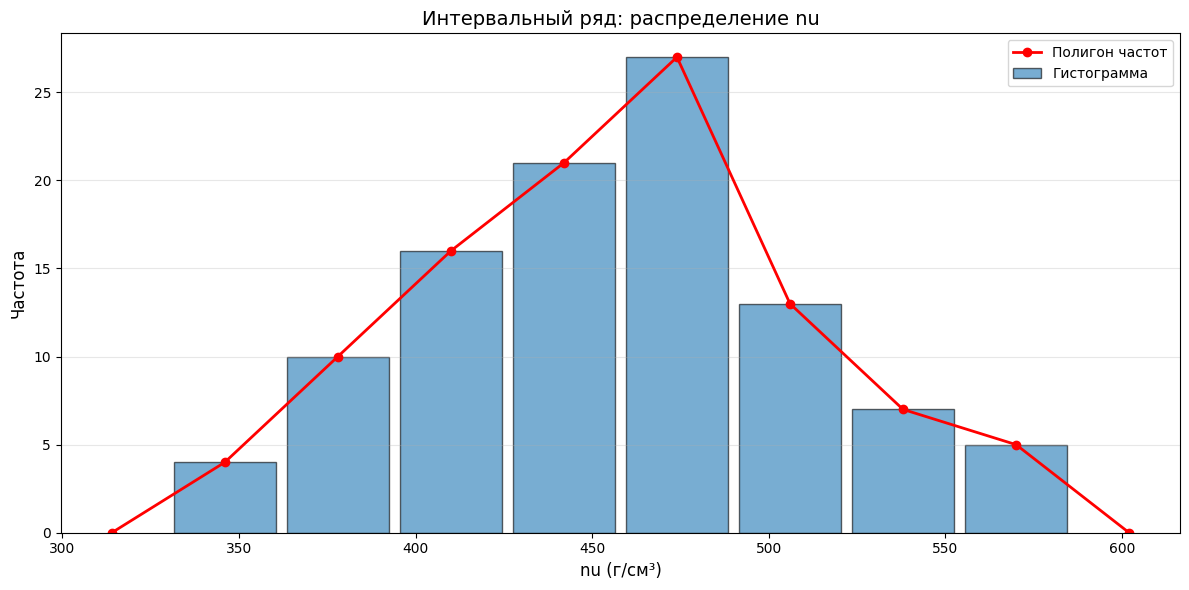

In [145]:
midpoints = interval_df['~xi'].values      # середины интервалов
frequencies = interval_df['mi'].values     # абсолютные частоты
intervals = interval_df['[xi, xi+1)'].values

width = midpoints[1] - midpoints[0]  # шаг между серединами = ширина интервала

plt.figure(figsize=(12, 6))

plt.bar(midpoints, frequencies, width=width*0.9,
        edgecolor='black', alpha=0.6, label='Гистограмма', align='center')

x_poly = np.concatenate([[midpoints[0] - width], midpoints, [midpoints[-1] + width]])
y_poly = np.concatenate([[0], frequencies, [0]])
plt.plot(x_poly, y_poly, 'ro-', linewidth=2, markersize=6,
         label='Полигон частот')

plt.xlabel('nu (г/см³)', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title('Интервальный ряд: распределение nu', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')
plt.legend()
plt.tight_layout()
plt.show()

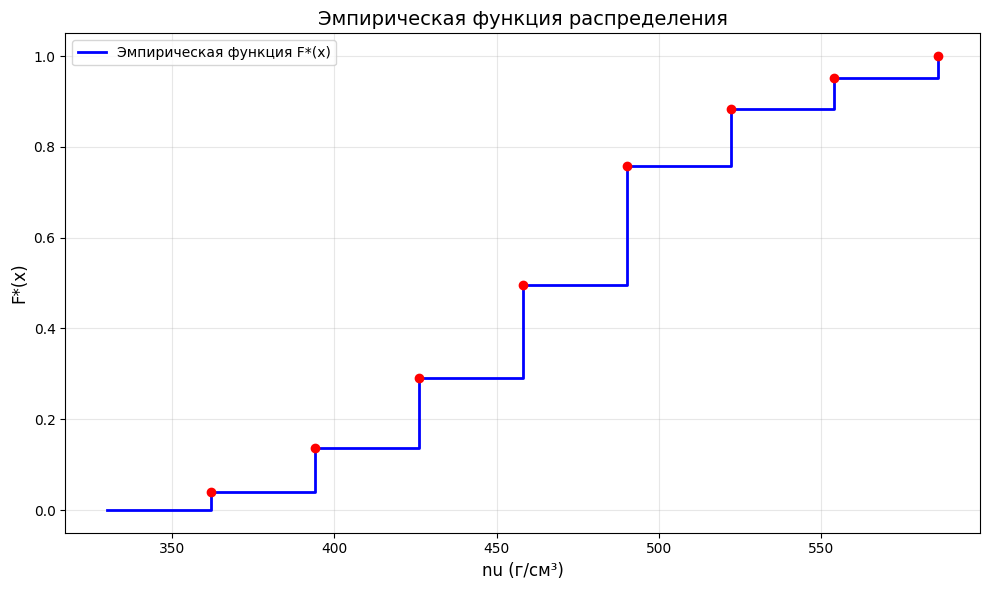

In [146]:
def parse_right_bound(interval_str):
    clean = interval_str.strip('[])').replace(' ', '')
    left, right = map(float, clean.split('-'))
    return right

right_bounds = [parse_right_bound(x) for x in interval_df['[xi, xi+1)']]
cum_freq = interval_df.iloc[:, 5].values / N  # столбец 'mi_нак'

x_ef = [right_bounds[0] - (right_bounds[1] - right_bounds[0])] + right_bounds
y_ef = [0] + list(cum_freq)

plt.figure(figsize=(10, 6))

plt.step(x_ef, y_ef, where='post', linewidth=2, color='blue', label='Эмпирическая функция F*(x)')
plt.plot(right_bounds, cum_freq, 'ro', markersize=6)

plt.xlabel('nu (г/см³)', fontsize=12)
plt.ylabel('F*(x)', fontsize=12)
plt.title('Эмпирическая функция распределения', fontsize=14)
plt.grid(True, alpha=0.3, axis='both')
plt.legend()
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

Построенные гистограмма и полигон частот подтверждают данные из таблицы: на графиках хорошо виден один пик в интервале [458.0–490.0), что указывает на наиболее часто встречающиеся значения признака. Форма графика симметрична относительно этого пика: частоты сначала растут, потом убывают. Эмпирическая функция распределения показывает, как накапливаются частоты: самый быстрый рост наблюдается в диапазоне 426–490 г/см³, где функция увеличивается с 0.29 до 0.76. К значению 490 г/см³ функция достигает 0.88, то есть 88% всех наблюдений не превышают этот порог.


#  Задание 6

Выполнить п. 5 для относительных частот. Сравнить результаты и сделать выводы.

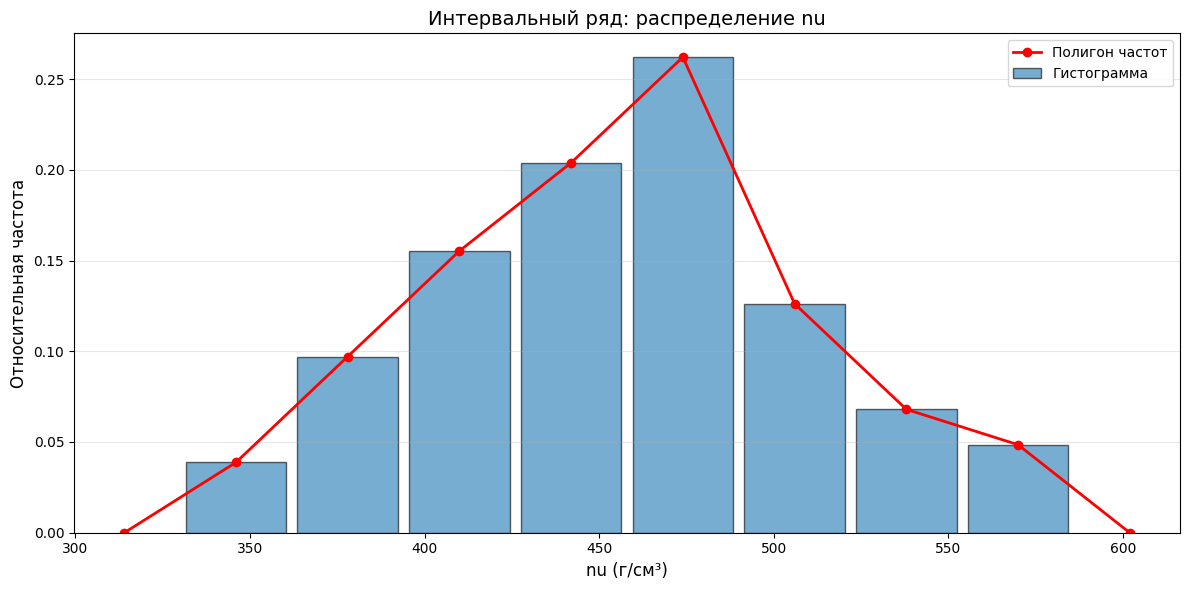

In [147]:
midpoints = interval_df['~xi'].values      # середины интервалов
frequencies = interval_df['~mi'].values     # абсолютные частоты
intervals = interval_df['[xi, xi+1)'].values

width = midpoints[1] - midpoints[0]  # шаг между серединами = ширина интервала

plt.figure(figsize=(12, 6))

plt.bar(midpoints, frequencies, width=width*0.9,
        edgecolor='black', alpha=0.6, label='Гистограмма', align='center')

x_poly = np.concatenate([[midpoints[0] - width], midpoints, [midpoints[-1] + width]])
y_poly = np.concatenate([[0], frequencies, [0]])
plt.plot(x_poly, y_poly, 'ro-', linewidth=2, markersize=6,
         label='Полигон частот')

plt.xlabel('nu (г/см³)', fontsize=12)
plt.ylabel('Относительная частота', fontsize=12)
plt.title('Интервальный ряд: распределение nu', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')
plt.legend()
plt.tight_layout()
plt.show()

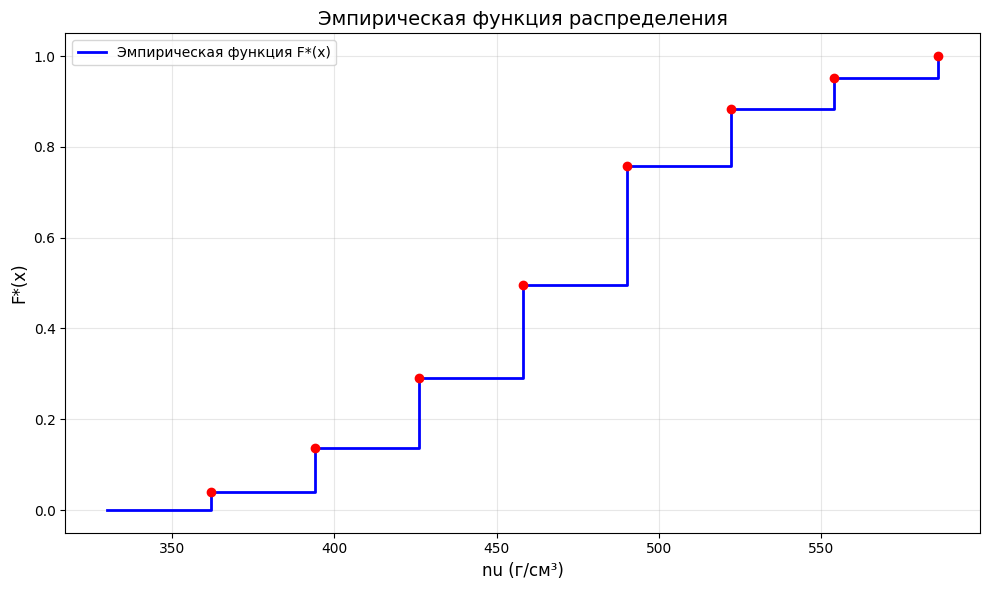

In [148]:
right_bounds = [parse_right_bound(x) for x in interval_df['[xi, xi+1)']]
cum_rel_freq = interval_df.iloc[:, 6].values  # столбец '~mi_нак'

x_ef = [right_bounds[0] - (right_bounds[1] - right_bounds[0])] + right_bounds
y_ef = [0] + list(cum_rel_freq)

plt.figure(figsize=(10, 6))

plt.step(x_ef, y_ef, where='post', linewidth=2, color='blue', label='Эмпирическая функция F*(x)')
plt.plot(right_bounds, cum_rel_freq, 'ro', markersize=6)

plt.xlabel('nu (г/см³)', fontsize=12)
plt.ylabel('F*(x)', fontsize=12)
plt.title('Эмпирическая функция распределения', fontsize=14)
plt.grid(True, alpha=0.3, axis='both')
plt.legend()
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

Графики, построенные для абсолютных и относительных частот, выглядят одинаково по форме: гистограммы и полигоны имеют один и тот же пик, интервалы расположены в тех же местах. Разница только в подписях по вертикальной оси: для абсолютных частот значения идут от 0 до 27, а для относительных — от 0 до 0.2621. Эмпирические функции распределения полностью совпадают, потому что относительные накопленные частоты получаются делением абсолютных на объём выборки N=103. Это значит, что переход к относительным частотам не меняет картину распределения, а только удобен для сравнения выборок разного размера.

# Выводы

## Общий вывод по проделанной работе

В ходе выполнения практической работы были освоены основные правила формирования выборки и подготовки данных к статистическому анализу. Из генеральной совокупности данных об объемном весе древесины резонансной ели была сформирована репрезентативная выборка объёмом 103 наблюдения с помощью случайного отбора в Python.

Исходные данные были последовательно преобразованы в ранжированный, вариационный и интервальный ряды. Построение интервального ряда с помощью формулы Стерджесса позволило выявить, что большинство значений объемного веса сосредоточено в диапазоне 426–490 г/см³.

Графическое представление данных в виде гистограммы, полигона частот и эмпирической функции распределения подтвердило выводы, сделанные по таблице: распределение имеет один ярко выраженный пик и симметричную форму. Сравнение графиков для абсолютных и относительных частот показало, что они полностью совпадают по форме — разница только в масштабе вертикальной оси, что подтверждает правильность расчётов.

Таким образом, в работе были закреплены практические навыки работы с выборочными данными: от формирования выборки до визуализации и интерпретации результатов. Полученные умения могут быть применены для анализа любых экспериментальных данных в научных и инженерных задачах.